## Exploring intersection of k-shells (and s-shells) and modules to investigate the presence of multi-cores. 

In [2]:
import networkx as nx
import random
import numpy as np
import itertools
import re
from collections import Counter
import seaborn as sns
import pandas as pd
import pickle 
import matplotlib.pyplot as plt

In [3]:
with open(r'data/processed/all_c_elegans_weighted_graphs.pkl', 'rb') as file:
    all_c_elegans_weighted_graphs = pickle.load(file)
    
stage_labels = ['L1-0', 'L1-5', 'L1-8', 'L1-16', 'L2', 'L3', 'Ad-45-1', 'Ad-45-2']

stage_labels_plot = ['L1$_{0h}$', 'L1$_{5h}$', 'L1$_{8h}$', 'L1$_{16h}$', 'L2', 'L3', 'Ad$^{1}$', 'Ad$^{2}$']

with open(r'data/processed/C_elegans_all_layers_kin_kcore_decomposition_all_stages.pkl', 'rb') as file:
    all_kin_k_cores_all_graphs = pickle.load(file)

with open(r'data/processed/C_elegans_all_layers_kout_kcore_decomposition_all_stages.pkl', 'rb') as file:
    all_kout_k_cores_all_graphs = pickle.load(file)

with open(r'data/processed/C_elegans_all_layers_kin_score_decomposition_all_stages.pkl', 'rb') as file:
    all_kin_s_cores_all_graphs = pickle.load(file)

with open(r'data/processed/C_elegans_all_layers_kout_score_decomposition_all_stages.pkl', 'rb') as file:
    all_kout_s_cores_all_graphs = pickle.load(file)

In [4]:
# It tells Matplotlib's mathtext engine to render math upright (roman) instead of the default italics — 
# without needing to wrap your labels in \mathrm{} or edit the list.
plt.rcParams['mathtext.default'] = 'regular' 

In [5]:
with open(r'data/processed/C_elegans_CCD_of_all_weighted_graphs.pkl', 'rb') as file:
    weighted_communities_all_stages = pickle.load(file)

In [6]:
def find_shells(dict_of_cores):

    '''Given a dictionary of k-cores or s-cores, this function returns the corresponding shells (occupancy)'''

    keys = list(dict_of_cores.keys())
    all_shells = dict()
    for idx in range(len(keys)):
        if idx < len(keys) - 1: # if it's not the last index then...
            shell = dict_of_cores[keys[idx]] - dict_of_cores[keys[idx+1]] # a k-shell comprises those k-core nodes which are absent in k+1 core
        else:
            shell = dict_of_cores[keys[idx]] # the last core has no core above it so, it becomes the shell
        if shell: # doesn't add empty shells
            all_shells[keys[idx]] = shell
            
    return all_shells

In [7]:
comms = sorted(weighted_communities_all_stages[1][0], key=len)

In [8]:
shells = find_shells(all_kout_s_cores_all_graphs[1])

In [9]:
def jaccard_similarity_matrix(shells, communities):
    
    n, m = len(list(shells.values())), len(communities)
    matrix = np.zeros((n, m))

    for i, set1 in enumerate(list(shells.values())):
        for j, set2 in enumerate(communities):
            intersection = len(set1 & set2)
            union = len(set1 | set2)
            matrix[i, j] = intersection / union 

    return matrix


**The Community Data for each  stage has three items: the renumbered communities, the renumbering reversed communities and the cooccurrence matrix**

In [31]:
for stage, community_data in weighted_communities_all_stages.items():
    communities_reverse_renumbering, communities_renumbered, cooccurrence_matrix = community_data
    print(stage, len(communities_reverse_renumbering), sorted([len(comm) for comm in communities_reverse_renumbering]))

0 4 [38, 42, 53, 54]
1 4 [38, 43, 48, 64]
2 5 [30, 37, 40, 44, 47]
3 7 [17, 20, 30, 32, 34, 35, 35]
4 5 [38, 39, 41, 42, 50]
5 6 [15, 22, 30, 32, 57, 60]
6 5 [21, 32, 38, 60, 70]
7 5 [31, 36, 37, 57, 58]


In [11]:
# ---------- helper for s-core shell compression ----------
def compress_s_shells(mat, shell_labels, n_top=5):
    """
    Keep:
      - first shell
      - one blank row
      - last n_top shells
    """
    n = len(shell_labels)
    if n <= n_top + 1:
        return mat, shell_labels

    keep_last_idx = list(range(n - n_top, n))
    kept_mat = mat[[0] + keep_last_idx, :]

    blank_row = np.full((1, mat.shape[1]), np.nan)
    new_mat = np.vstack([kept_mat[:1], blank_row, kept_mat[1:]])

    new_labels = [shell_labels[0], ""] + [shell_labels[i] for i in keep_last_idx]
    return new_mat, new_labels

**Final Plot**

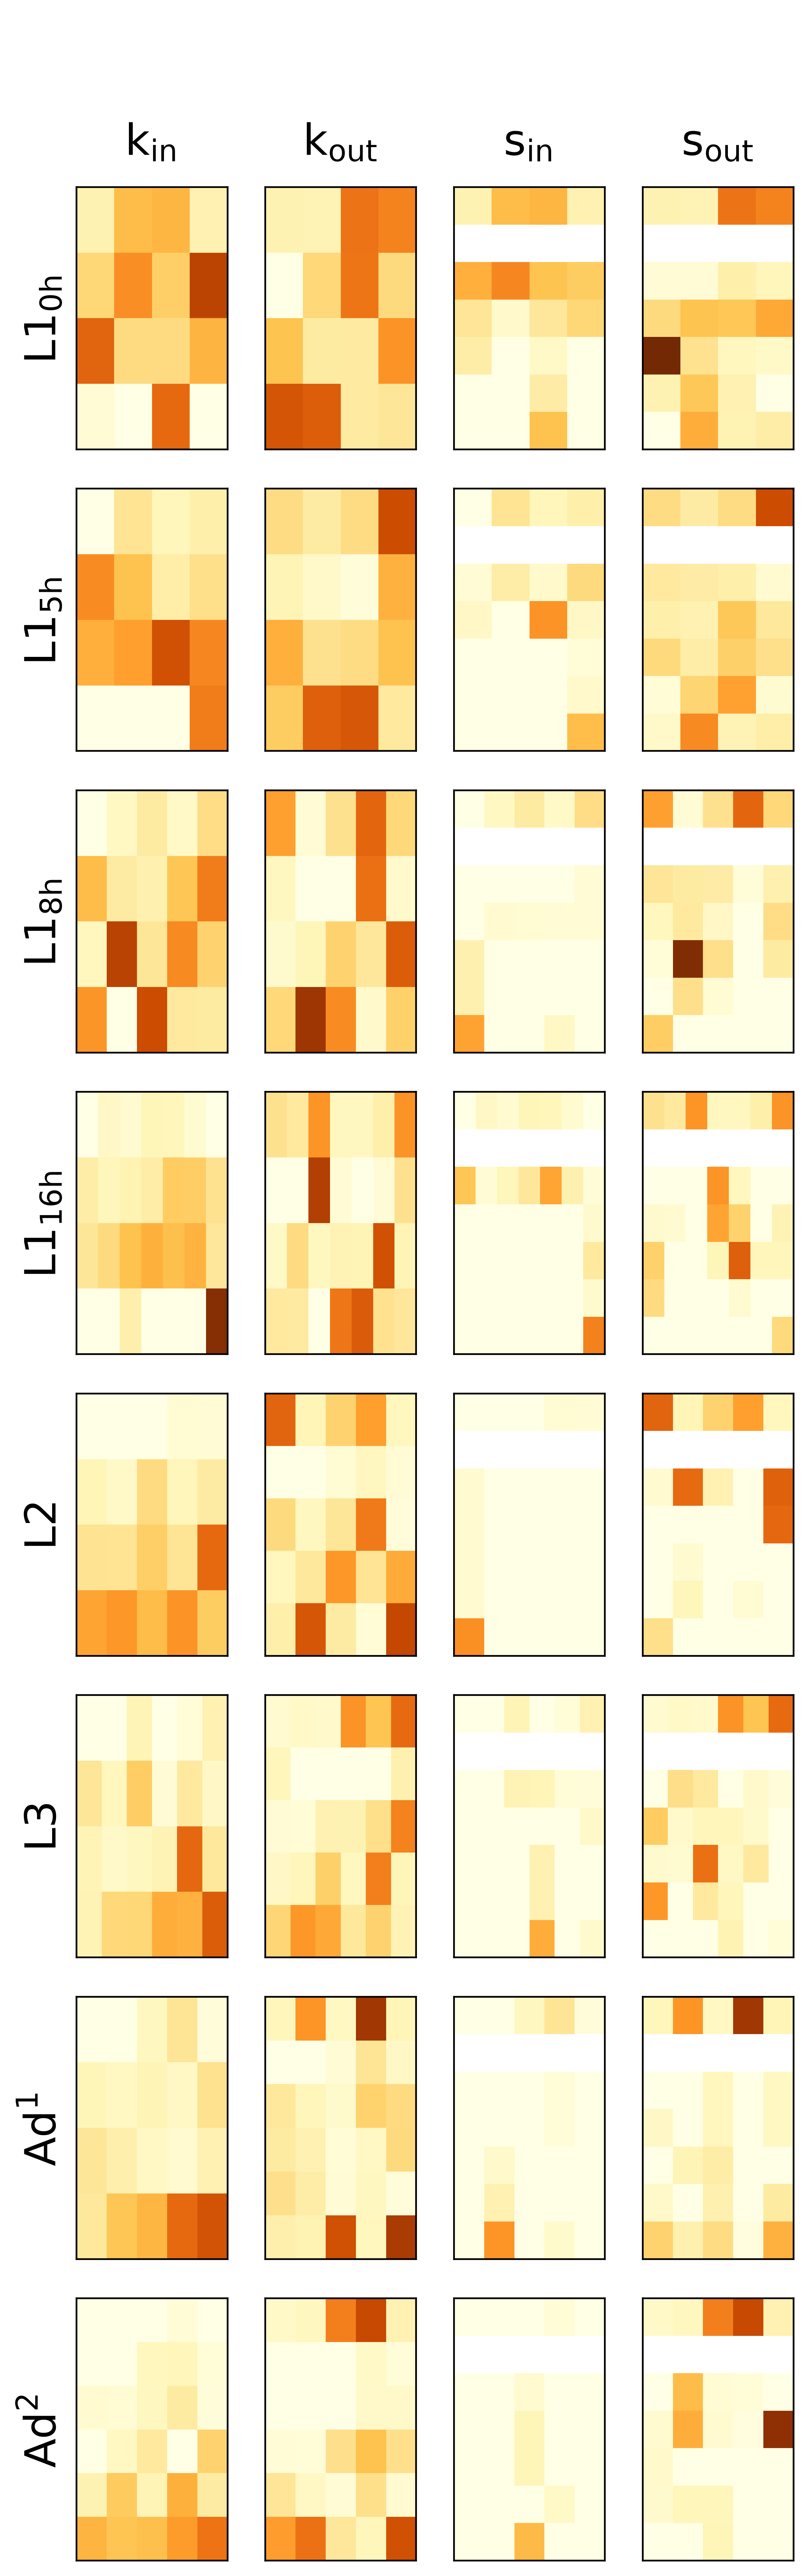

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ---------- figure ----------
fig, axes = plt.subplots(
    len(all_c_elegans_weighted_graphs), 4,
    dpi=500,
    figsize=(6, len(all_c_elegans_weighted_graphs) * 2.5)
)

core_labels = ['\n\n$k_{in}$', '\n\n$k_{out}$', '\n\n$s_{in}$', '\n\n$s_{out}$']

vmin, vmax = 0, 0.4

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap="YlOrBr")
sm.set_array([])

import matplotlib as mpl
cmap = mpl.colormaps.get_cmap("YlOrBr").copy()

cmap.set_bad("white")   # NaN row → blank

# ---------- main loop ----------
for idx, graph in enumerate(all_c_elegans_weighted_graphs):

    kin_k_shells  = find_shells(all_kin_k_cores_all_graphs[idx])
    kout_k_shells = find_shells(all_kout_k_cores_all_graphs[idx])
    kin_s_shells  = find_shells(all_kin_s_cores_all_graphs[idx])
    kout_s_shells = find_shells(all_kout_s_cores_all_graphs[idx])

    communities = sorted(weighted_communities_all_stages[idx][0], key=len)

    matrix_kin_k  = jaccard_similarity_matrix(kin_k_shells, communities)
    matrix_kout_k = jaccard_similarity_matrix(kout_k_shells, communities)
    matrix_kin_s  = jaccard_similarity_matrix(kin_s_shells, communities)
    matrix_kout_s = jaccard_similarity_matrix(kout_s_shells, communities)

    matrices = [matrix_kin_k, matrix_kout_k, matrix_kin_s, matrix_kout_s]
    shells_list = [kin_k_shells, kout_k_shells, kin_s_shells, kout_s_shells]

    for j in range(4):
        ax = axes[idx, j] if len(all_c_elegans_weighted_graphs) > 1 else axes[j]

        mat = matrices[j]
        shell_labels = list(shells_list[j].keys())

        # ---- APPLY ONLY TO s-CORES ----
        if j in (2, 3):
            mat, shell_labels = compress_s_shells(mat, shell_labels, n_top=5)

        im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.set_xticks([])

        if idx == 0:
            ax.set_title(core_labels[j], pad=15, fontsize=20)
        if j == 0:
            ax.set_ylabel(stage_labels_plot[idx], labelpad=5, rotation=90, fontsize=20)

        ax.tick_params(axis='both', labelsize=10)

plt.subplots_adjust(hspace=0.15, wspace=0.25)

plt.show()


**Plotting colobar separately**

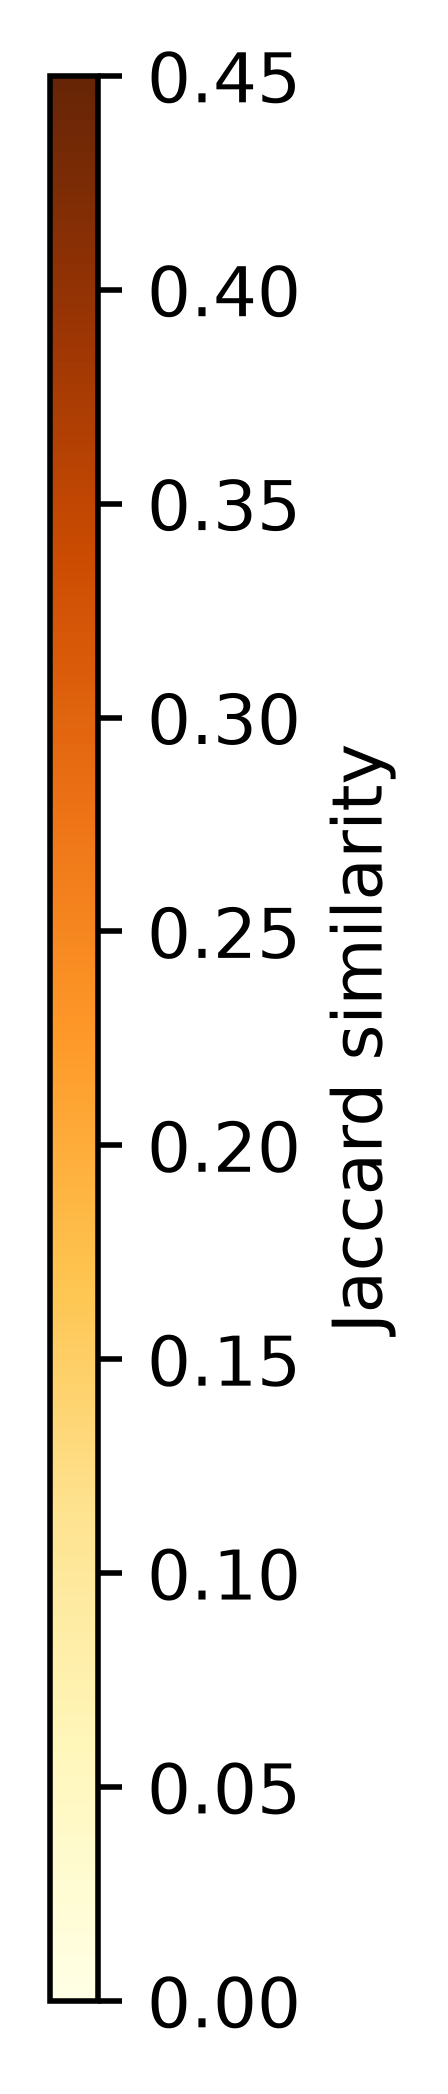

In [13]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

norm = Normalize(vmin=0, vmax=0.45)
sm = ScalarMappable(norm=norm, cmap="YlOrBr")
sm.set_array([])

fig, ax = plt.subplots(figsize=(0.125, 5), dpi=500)
cbar = fig.colorbar(sm, cax=ax)

cbar.set_label("Jaccard similarity", fontsize=10)
cbar.ax.tick_params(labelsize=10)

plt.show()
